# Kappa - Daughter-specific chromatin changes tuning


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [688]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')
chromatin_model1 = ChromatinModel(config1)


todo: Loading testing config from replication deconvolution


In [817]:
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
orfname = get_orfname('SSK22')

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
mnase_span = tss-200, tss+200

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

Loading chromosome reads: 3
Applying a normalization for length distribution


In [818]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

In [819]:
from src.chromatin_deconvolution_solver import dummy_N_frep_b, \
    subset_select_highest_G_indices

N, f_rep, b = dummy_N_frep_b(config1)
G_values, highest_Gs = subset_select_highest_G_indices(chromatin_model.G)
chromatin_solver = ChromatinDeconvolveSolver(config1, G_values, N, b, f_rep)

Completed. - 00:00:46.840


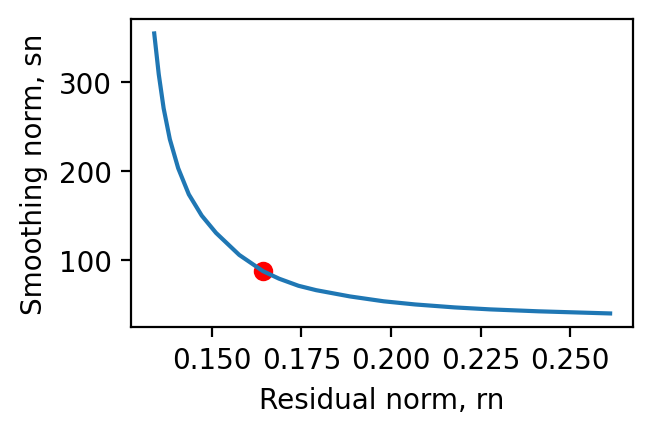

In [820]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.00001,
                                            gamma_max=0.01, verbose=False,
                                            kappa=0.01)
chrom_find_gamma.find_optimal_gamma()

In [821]:
optimal_gamma = chrom_find_gamma.gamma_optimizer.optimal_gamma
print("Initial gamma to begin kappa sweep: ", optimal_gamma)

Initial gamma to begin kappa sweep:  0.0004209872049214969


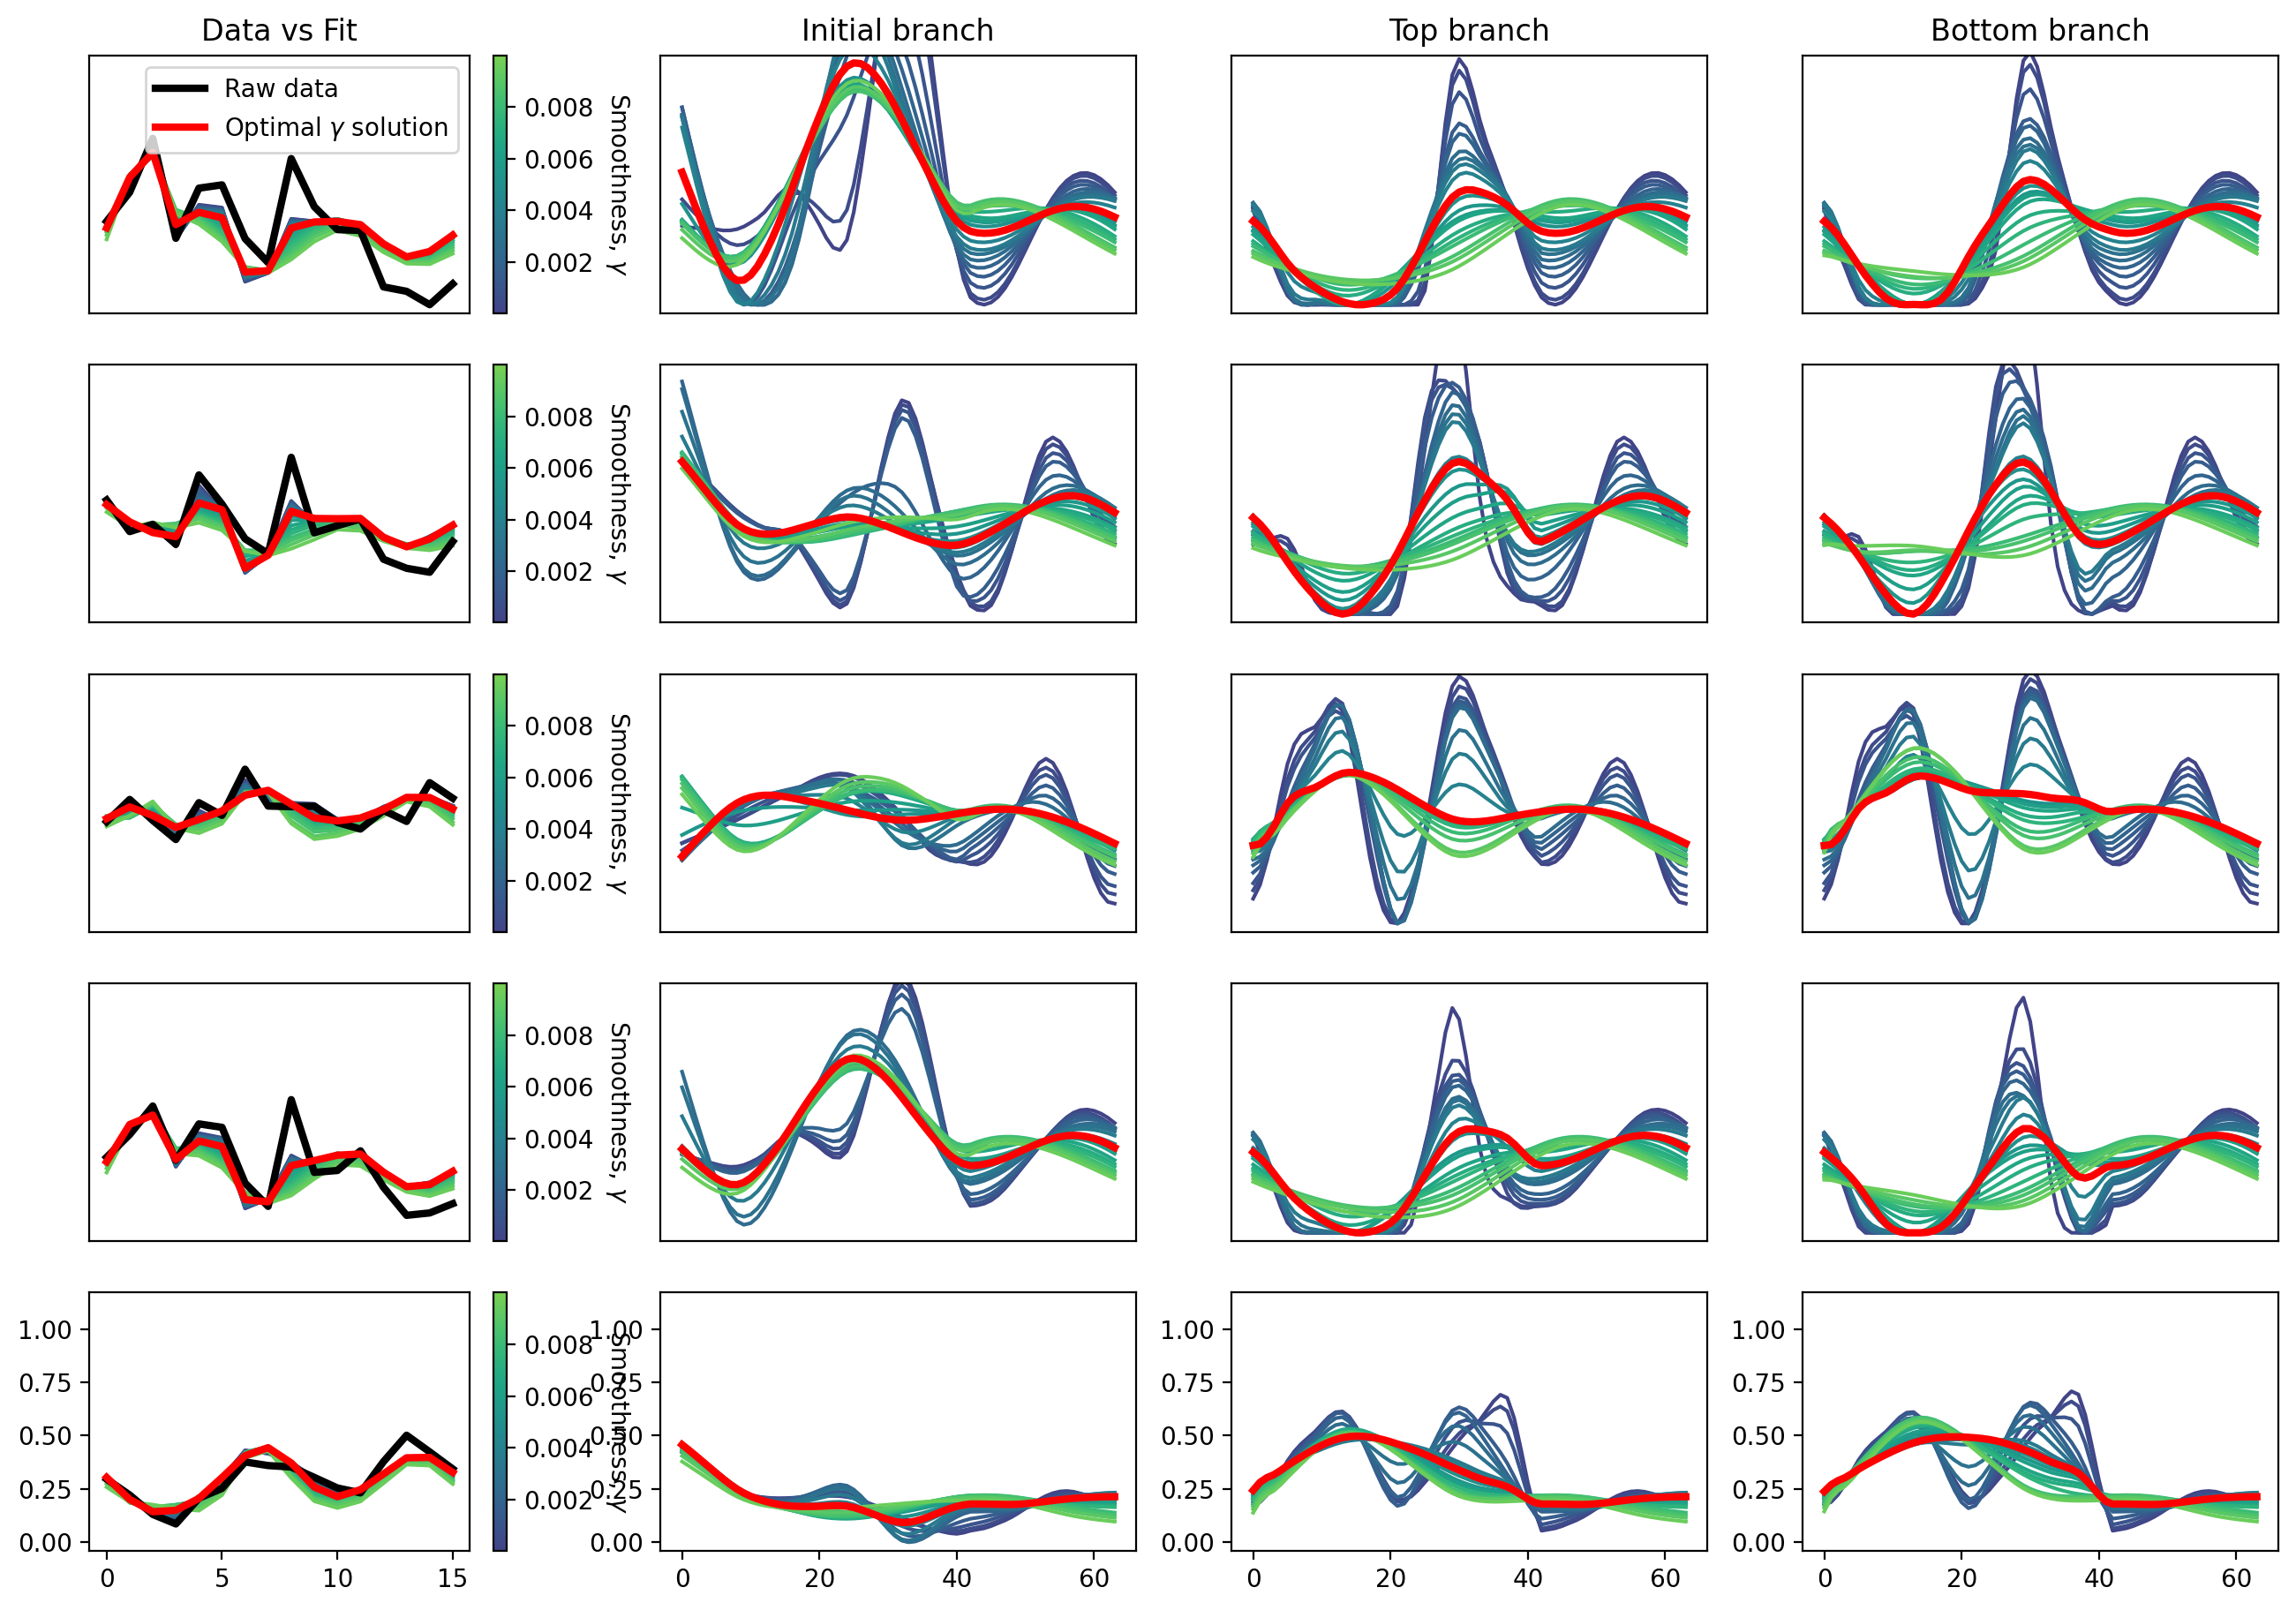

In [822]:
_ = chrom_find_gamma.plot_gamma_sweep()

Next, we are interested in DSE1 and SSK22as our initial signal to noise genes. 

Let's look at the chromatin for each of these, we are looking in the raw data for where
the signal should be for DSE1.

In [801]:
from src.utils import mkdir_safe
from src.chromatin_deconvolution_solver import plot_example_fits
from src.chromatin_deconvolution_solver import plot_branches
from src.chromatin_model import plot_prediction
from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname
from src.RealDataReplication import read_n_fr_b
from src.chromatin_deconvolution_solver import subset_select_highest_G_indices

def deconvolve_and_plot(gene_name, gamma, kappa, output_directory,
                       padding=1200):
    genes = get_deconvolved_geneset()

    orfname = get_orfname(gene_name)

    gene = genes.loc[orfname]
    tss = gene.TSS
    chrom = gene.chr
    padding_2 = padding//2
    mnase_span = tss-padding_2, tss+padding_2
    _, N, frep, b = read_n_fr_b(chrom, mnase_span)
    
    chromatin_model = ChromatinModel(config1)
    chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

    chromatin_solver = ChromatinDeconvolveSolver(config1, 
        chromatin_model.G, N, b, frep)
    full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(gamma=gamma, 
        kappa=kappa)

    np.save(f"{output_directory}/{gene_name}_F.npy", full_deconvolved_F)

    fig = plot_branches(chromatin_model, full_deconvolved_F)
    plt.savefig(f"{output_directory}/{gene_name}_branches.png")
    plt.close(fig)

    fig = plot_prediction(chromatin_model, N, full_deconvolved_F, f_rep, b)
    plt.savefig(f"{output_directory}/{gene_name}_prediction.png")
    plt.close(fig)

    fig = plot_example_fits(chromatin_solver)
    plt.savefig(f"{output_directory}/{gene_name}_curves.png")
    plt.close(fig)

output_directory = 'output/daughter_specific_chromatin_sweep_gm0004_kappa001'
mkdir_safe(output_directory)


In [ ]:
from src.timer import Timer

gene_names = ['DSE1', 'SSK22', 'DSE2', 'CLB2', 'MCM6']
timer = Timer()

for gene_name in gene_names:
    print(gene_name)
    deconvolve_and_plot(gene_name, gamma, kappa, output_directory, padding=1200)
    timer.print_time()
